# Tipping Point Experiment Analysis
This notebook visualizes the results of the tipping point experiment, which varies the proportion of `adverse` agents in the population.

In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [13]:
plt.rcParams.update({
    'font.size': 14
})

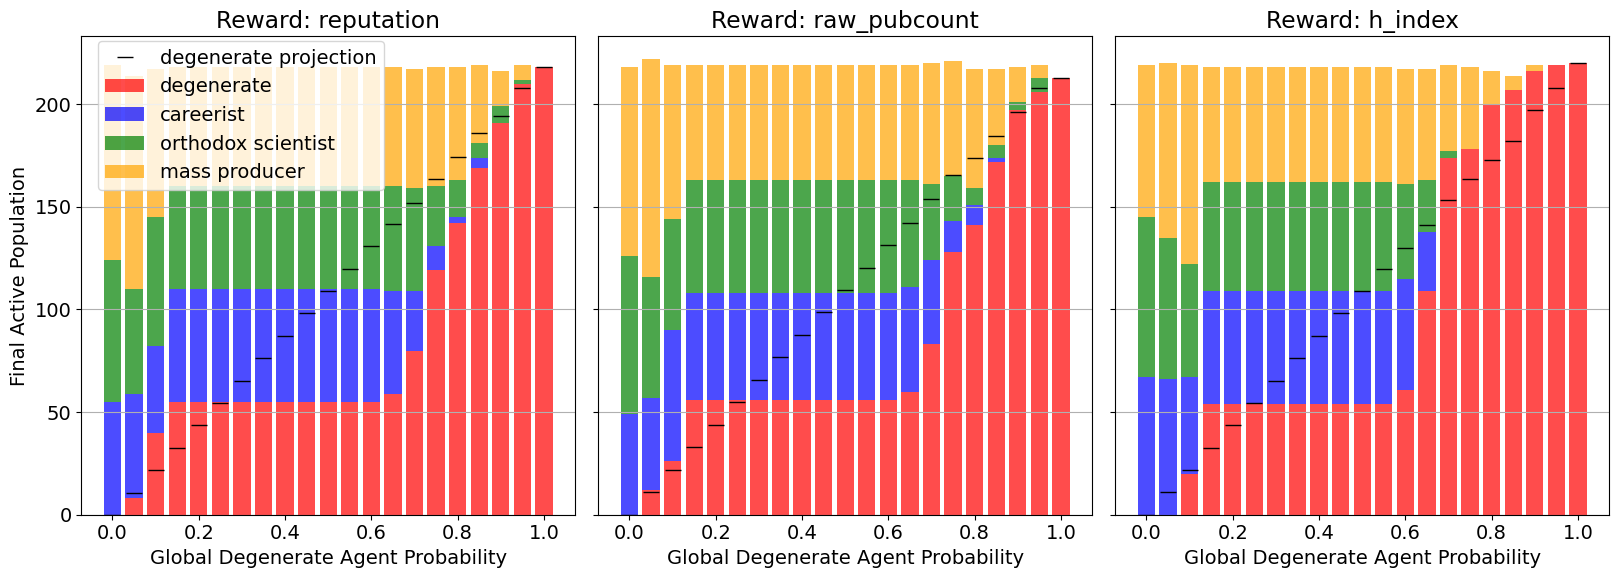

In [14]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

reward_types = ['reputation', 'raw_pubcount', 'h_index']
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

colors = {
    'adverse': 'red',
    'careerist': 'blue',
    'orthodox_scientist': 'green',
    'mass_producer': 'orange'
}

display_labels = {
    'adverse': 'degenerate',
    'careerist': 'careerist',
    'orthodox_scientist': 'orthodox scientist',
    'mass_producer': 'mass producer'
}

for i, reward_type in enumerate(reward_types):
    ax = axes[i]
    filepath = f"log/tipping_point_experiment_{reward_type}_results.json"
    
    data = []
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            # handle jsonl
            try:
                for line in f:
                    if line.strip():
                        data.append(json.loads(line))
            except json.JSONDecodeError:
                # maybe it's just a normal json list but named .jsonl
                f.seek(0)
                data = json.load(f)
    else:
        print("FILE NOT FOUND.")
                
    if data:
        proportions = [d['adverse_proportion'] for d in data]
        populations = {
            'adverse': [],
            'careerist': [],
            'orthodox_scientist': [],
            'mass_producer': []
        }
        for d in data:
            pops = d['final_populations']
            for k in populations.keys():
                populations[k].append(pops.get(k, 0))
                
        bottom = np.zeros(len(proportions))

        for policy, counts in populations.items():

            ax.bar(
                proportions,
                counts,
                width=0.04,
                label=display_labels.get(policy, policy),
                bottom=bottom,
                color=colors.get(policy, 'gray'),
                alpha=0.7
            )

            bottom += np.array(counts)

        # -----------------------------------
        # Black indicator:
        # expected degenerate proportion
        # -----------------------------------

        indicator_y = np.array(proportions) * bottom

        ax.plot(
            proportions,
            indicator_y,
            color='black',
            linewidth=2,
            linestyle='',
            marker='_',
            markersize=12,
            label='degenerate projection'
        )
            
        ax.set_title(f'Reward: {reward_type}')
        ax.set_xlabel('Global Degenerate Agent Probability')
        if i == 0:
            ax.set_ylabel('Final Active Population')
        ax.grid(True, axis='y')
    else:
        ax.text(0.5, 0.5, f"Data not found\n{filepath}", ha='center', va='center')
        ax.set_title(f'Reward: {reward_type}')

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.225, 0.93))

# plt.suptitle('Tipping Point: Final Population Composition across Reward Types', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(right=0.9)
plt.show()
